In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [2]:
# Importing Dataset
review_df = pd.read_csv(
    "..\\Data\\Cleaned_Data\\merged_dataset.csv"
)

review_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Updated_Year,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Review_length,Word_count,Sentiment_Label,Subjectivity_Category,Polarity_Type
0,GollerCepte Live Score,SPORTS,4.2,9992,31.000000,1000000,Free,0.0,Everyone,Sports,...,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,0.088867,100000,Free,0.0,Everyone,Tools,...,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18.000000,1000000,Free,0.0,Everyone,Shopping,...,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33.000000,1000000,Free,0.0,Everyone,Sports,...,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.000000,500000,Free,0.0,Teen,Travel & Local,...,2018,I'm grateful booking engine dreamtrips. I've a...,Positive,0.2,0.2,150.0,21.0,1.0,Low,Neutral


In [3]:
review_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Updated_Month', 'Updated_Year', 'Translated_Review',
       'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity',
       'Review_length', 'Word_count', 'Sentiment_Label',
       'Subjectivity_Category', 'Polarity_Type'],
      dtype='str')

In [4]:
review_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35624 entries, 0 to 35623
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     35624 non-null  str    
 1   Category                35624 non-null  str    
 2   Rating                  35624 non-null  float64
 3   Reviews                 35624 non-null  int64  
 4   Size                    35624 non-null  float64
 5   Installs                35624 non-null  int64  
 6   Type                    35624 non-null  str    
 7   Price                   35624 non-null  float64
 8   Content Rating          35624 non-null  str    
 9   Genres                  35624 non-null  str    
 10  Last Updated            35624 non-null  str    
 11  Current Ver             35624 non-null  str    
 12  Android Ver             35624 non-null  str    
 13  Updated_Month           35624 non-null  int64  
 14  Updated_Year            35624 non-null  int64  
 

In [5]:
review_df.isnull().sum()

App                          0
Category                     0
Rating                       0
Reviews                      0
Size                         0
Installs                     0
Type                         0
Price                        0
Content Rating               0
Genres                       0
Last Updated                 0
Current Ver                  0
Android Ver                  0
Updated_Month                0
Updated_Year                 0
Translated_Review         7374
Sentiment                 7374
Sentiment_Polarity        7374
Sentiment_Subjectivity    7374
Review_length             7374
Word_count                7374
Sentiment_Label           7374
Subjectivity_Category     7374
Polarity_Type             7374
dtype: int64

In [6]:
review_df = review_df.dropna(
    subset=["Translated_Review"]
)

In [7]:
review_df.describe(include="all")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Updated_Year,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Review_length,Word_count,Sentiment_Label,Subjectivity_Category,Polarity_Type
count,28250,28250,28250.000000,2.825000e+04,28250.000000,2.825000e+04,28250,28250.000000,28250,28250,...,28250.000000,28250,28250,28250.000000,28250.000000,28250.000000,28250.000000,28250.000000,28250,28250
unique,816,33,NaN,NaN,NaN,NaN,2,NaN,5,68,...,NaN,26682,3,NaN,NaN,NaN,NaN,NaN,3,2
top,Facebook,GAME,NaN,NaN,NaN,NaN,Free,NaN,Everyone,Health & Fitness,...,NaN,Good,Positive,NaN,NaN,NaN,NaN,NaN,Medium,Neutral
freq,130,3879,NaN,NaN,NaN,NaN,27947,NaN,22295,1621,...,NaN,124,18140,NaN,NaN,NaN,NaN,NaN,17003,22193
mean,NaN,NaN,4.290074,1.184685e+06,23.101572,3.274855e+07,NaN,0.103733,NaN,NaN,...,2017.694301,NaN,NaN,0.188273,0.492303,107.961416,17.454478,0.498655,NaN,NaN
std,NaN,NaN,0.309059,5.927683e+06,22.337421,1.249355e+08,NaN,1.344401,NaN,NaN,...,0.844319,NaN,NaN,0.354657,0.264011,103.098841,16.232141,0.732772,NaN,NaN
min,NaN,NaN,2.600000,1.140000e+02,0.008301,1.000000e+03,NaN,0.000000,NaN,NaN,...,2011.000000,NaN,NaN,-1.000000,0.000000,2.000000,1.000000,-1.000000,NaN,NaN
25%,NaN,NaN,4.100000,8.723000e+03,12.000000,1.000000e+06,NaN,0.000000,NaN,NaN,...,2018.000000,NaN,NaN,0.000000,0.350000,31.000000,5.000000,0.000000,NaN,NaN
50%,NaN,NaN,4.300000,5.154300e+04,13.000000,5.000000e+06,NaN,0.000000,NaN,NaN,...,2018.000000,NaN,NaN,0.157143,0.515829,81.000000,13.000000,1.000000,NaN,NaN
75%,NaN,NaN,4.500000,3.100950e+05,27.000000,1.000000e+07,NaN,0.000000,NaN,NaN,...,2018.000000,NaN,NaN,0.419117,0.650000,155.000000,25.000000,1.000000,NaN,NaN


## Sentiment Distribution

In [8]:
# Sentiment counts
review_df["Sentiment"].value_counts()

Sentiment
Positive    18140
Negative     6057
Neutral      4053
Name: count, dtype: int64

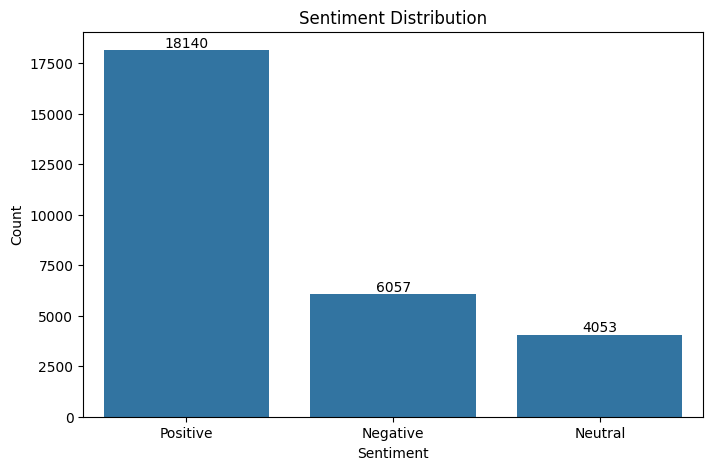

In [9]:
# Plot Sentiment Distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=review_df["Sentiment"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Subjectivity Analysis

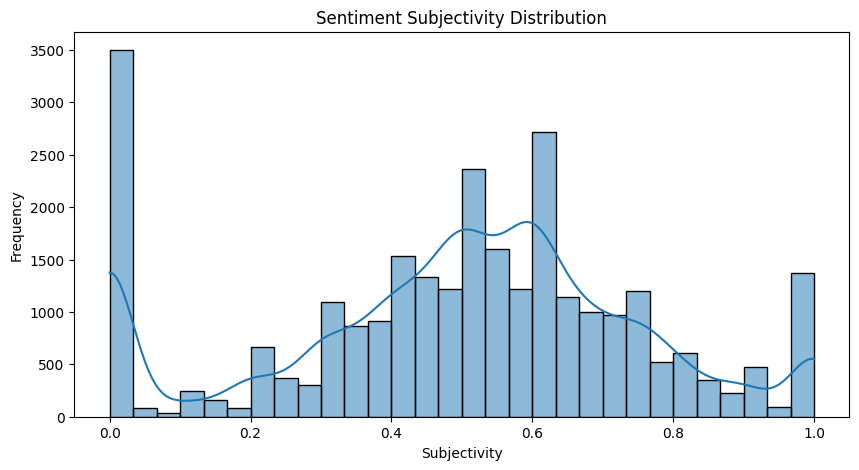

In [10]:
# Subjectivity Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    review_df["Sentiment_Subjectivity"],
    bins=30,
    kde=True
)

plt.title("Sentiment Subjectivity Distribution")
plt.xlabel("Subjectivity")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Subjectivity Category Counts
review_df["Subjectivity_Category"].value_counts()

Subjectivity_Category
Medium    17003
High       5807
Low        5440
Name: count, dtype: int64

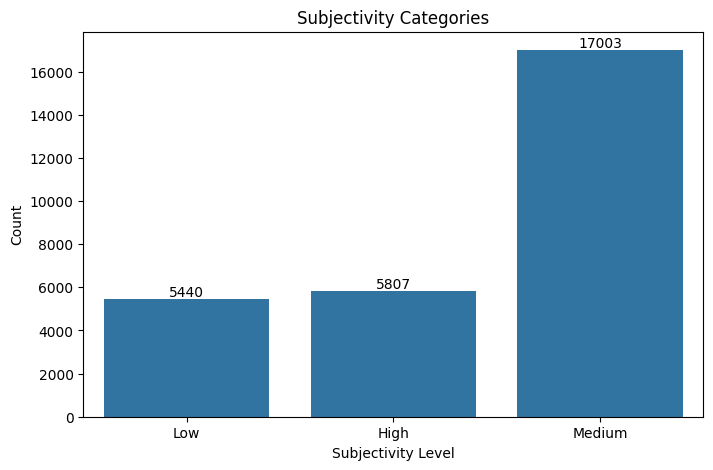

In [12]:
# Plot Subjectivity Categories
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=review_df["Subjectivity_Category"]
)

plt.title("Subjectivity Categories")
plt.xlabel("Subjectivity Level")
plt.ylabel("Count")

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Polarity Analysis

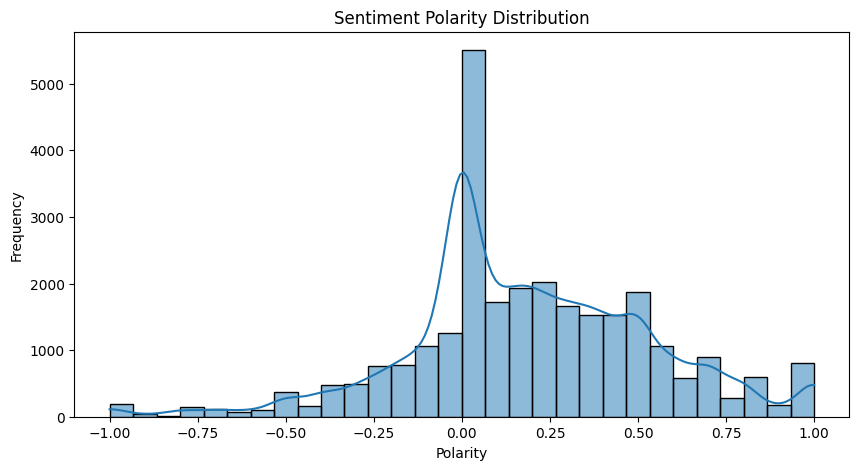

In [13]:
# Polarity Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    review_df["Sentiment_Polarity"],
    bins=30,
    kde=True
)

plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")

plt.show()

In [14]:
review_df["Polarity_Type"].value_counts()

Polarity_Type
Neutral     22193
Positive     6057
Name: count, dtype: int64

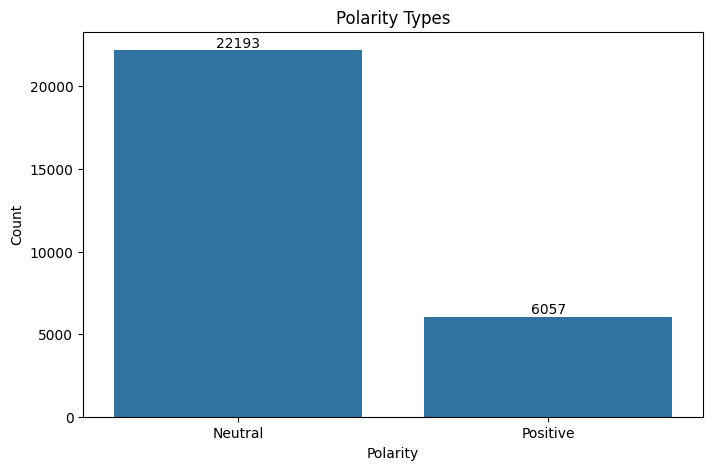

In [15]:
# Plot Polarity Types
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=review_df["Polarity_Type"]
)

plt.title("Polarity Types")
plt.xlabel("Polarity")
plt.ylabel("Count")

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Review Length & Word Count Analysis

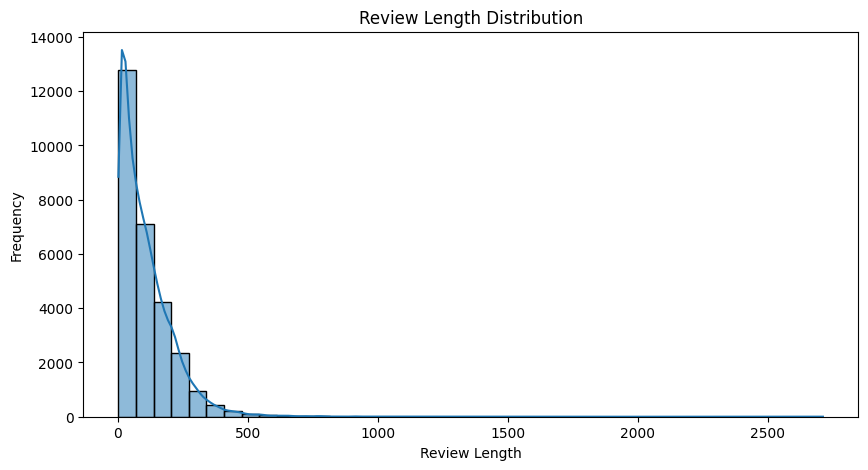

In [16]:
# Review Length Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    review_df["Review_length"],
    bins=40,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

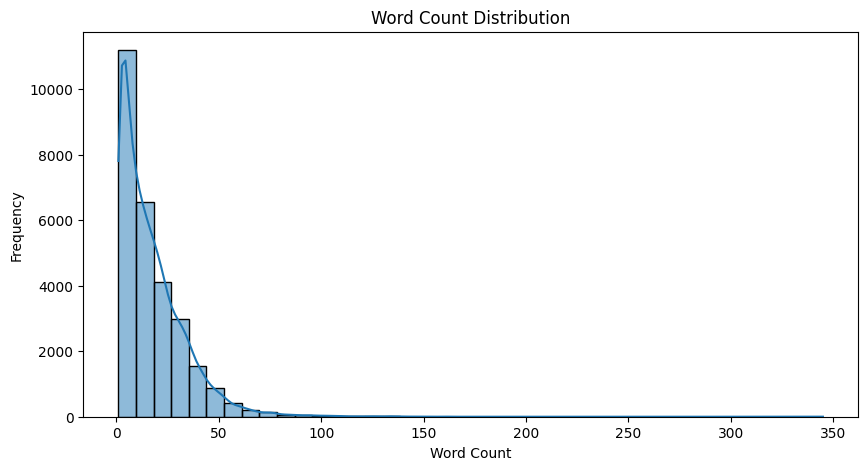

In [17]:
# Word Count Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    review_df["Word_count"],
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

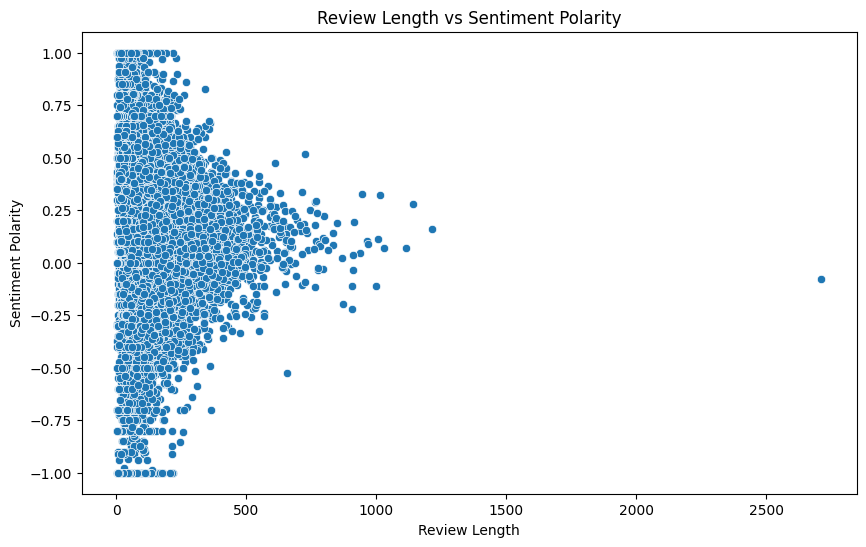

In [18]:
# Scatterplot Review Length vs Polarity
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=review_df["Review_length"],
    y=review_df["Sentiment_Polarity"]
)

plt.title("Review Length vs Sentiment Polarity")

plt.xlabel("Review Length")
plt.ylabel("Sentiment Polarity")

plt.show()

## Word Count vs. Subjectivity

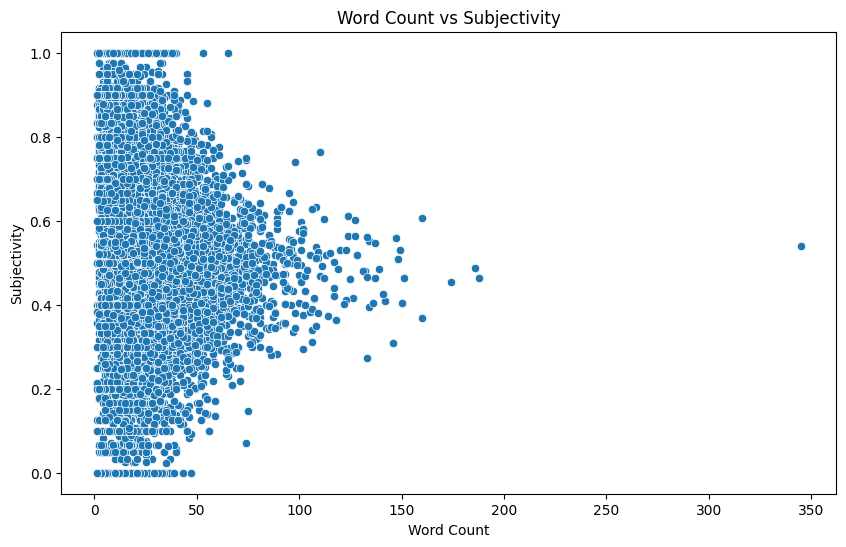

In [19]:
# Scatterplot Word Count vs Subjectivity
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=review_df["Word_count"],
    y=review_df["Sentiment_Subjectivity"]
)

plt.title("Word Count vs Subjectivity")

plt.xlabel("Word Count")
plt.ylabel("Subjectivity")

plt.show()

## Category-wise Sentiment Analysis

In [20]:
# Average Sentiment Polarity by Category
category_polarity = (
    review_df.groupby("Category")[
        "Sentiment_Polarity"
    ]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_polarity

Category
COMICS                 0.449810
EVENTS                 0.375086
AUTO_AND_VEHICLES      0.343119
PARENTING              0.313316
EDUCATION              0.298493
HEALTH_AND_FITNESS     0.294396
WEATHER                0.281344
FOOD_AND_DRINK         0.279847
PERSONALIZATION        0.274741
MAPS_AND_NAVIGATION    0.259767
Name: Sentiment_Polarity, dtype: float64

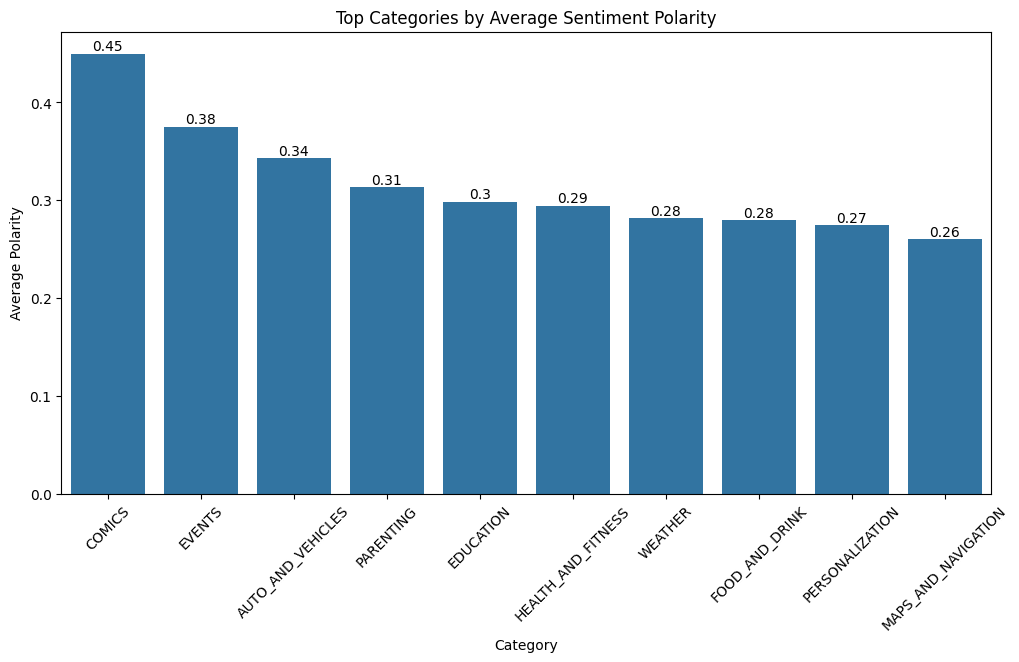

In [21]:
# Plot Average Polarity by Category
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=category_polarity.index,
    y=category_polarity.values
)

plt.xticks(rotation=45)

plt.title("Top Categories by Average Sentiment Polarity")

plt.xlabel("Category")
plt.ylabel("Average Polarity")

# Add labels
for i, value in enumerate(category_polarity.values):

    ax.text(
        i,
        value,
        round(value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

## Category-wise Subjectivity Analysis

In [22]:
# Average Subjectivity by Category
category_subjectivity = (
    review_df.groupby("Category")[
        "Sentiment_Subjectivity"
    ]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_subjectivity

Category
EVENTS                0.571383
COMICS                0.570933
LIBRARIES_AND_DEMO    0.525752
FOOD_AND_DRINK        0.525431
AUTO_AND_VEHICLES     0.525134
PERSONALIZATION       0.524561
ART_AND_DESIGN        0.521388
HEALTH_AND_FITNESS    0.512705
EDUCATION             0.508191
DATING                0.506061
Name: Sentiment_Subjectivity, dtype: float64

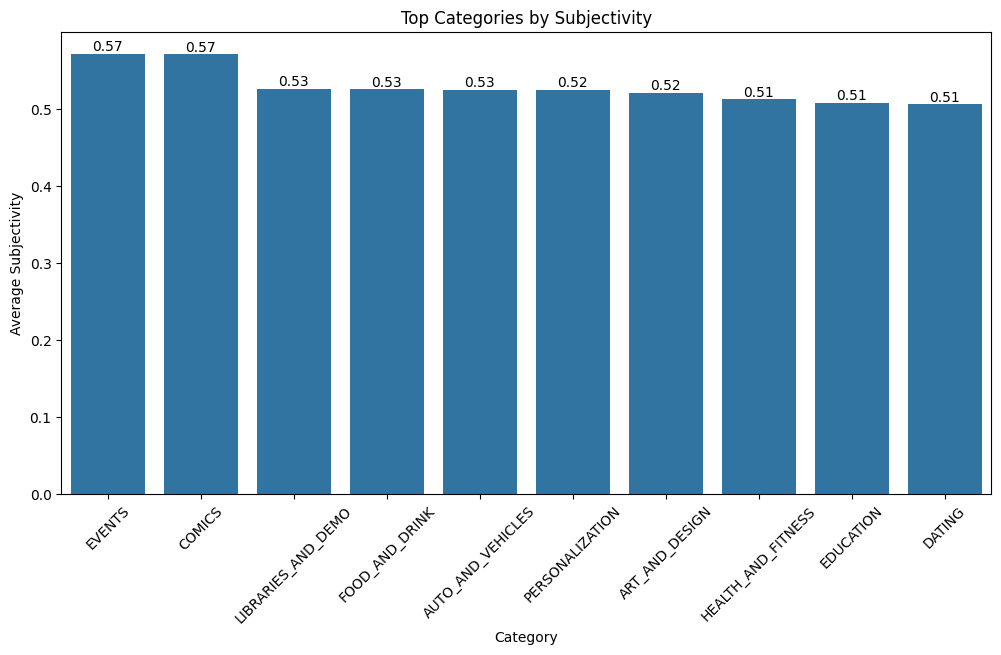

In [23]:
# Plot Subjectivity by Category
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=category_subjectivity.index,
    y=category_subjectivity.values
)

plt.xticks(rotation=45)

plt.title("Top Categories by Subjectivity")

plt.xlabel("Category")
plt.ylabel("Average Subjectivity")

# Add labels
for i, value in enumerate(category_subjectivity.values):

    ax.text(
        i,
        value,
        round(value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

## Category-wise Sentiment Count

In [24]:
# Sentiment Counts by Category
sentiment_category = pd.crosstab(
    review_df["Category"],
    review_df["Sentiment"]
)

sentiment_category.head()

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,47,58,229
AUTO_AND_VEHICLES,17,36,230
BEAUTY,60,81,176
BOOKS_AND_REFERENCE,84,106,427
BUSINESS,115,163,379


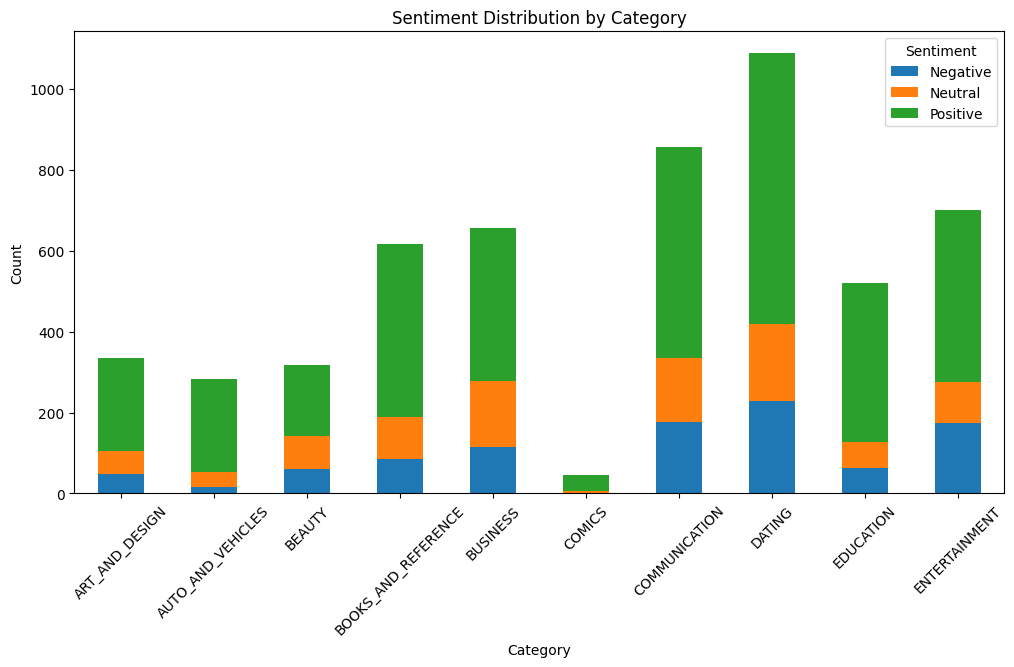

In [25]:
# Plot Stacked Sentiment Counts
sentiment_category.head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Category")

plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Correlation Analysis

In [26]:
# Create Correlation Matrix
correlation_cols = [
    "Sentiment_Polarity",
    "Sentiment_Subjectivity",
    "Review_length",
    "Word_count"
]

corr_matrix = review_df[
    correlation_cols
].corr()

corr_matrix

,Sentiment_Polarity,Sentiment_Subjectivity,Review_length,Word_count
Sentiment_Polarity,1.000000,0.271602,-0.153106,-0.153378
Sentiment_Subjectivity,0.271602,1.000000,0.029455,0.026383
Review_length,-0.153106,0.029455,1.000000,0.989485
Word_count,-0.153378,0.026383,0.989485,1.000000


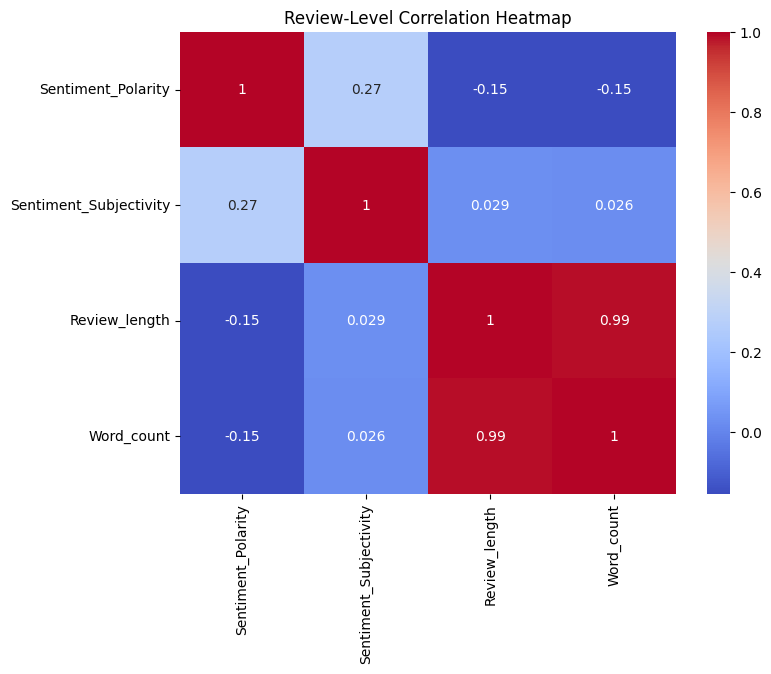

In [27]:
# Plot Correlation Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Review-Level Correlation Heatmap")

plt.show()

## Top Positive & Negative Apps

In [28]:
# Top Positive Apps
top_positive_apps = (
    review_df.groupby("App")[
        "Sentiment_Polarity"
    ]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_positive_apps

App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.650000
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64

In [29]:
# Top Negative Apps
top_negative_apps = (
    review_df.groupby("App")[
        "Sentiment_Polarity"
    ]
    .mean()
    .sort_values()
    .head(10)
)

top_negative_apps

App
Google Street View               -0.500000
DEER HUNTER 2018                 -0.383333
Fruit Block - Puzzle Legend      -0.183333
Call of Duty:Black Ops Zombies   -0.162120
Draw A Stickman                  -0.150000
Guns of Glory                    -0.142060
Hitwe - meet people and chat     -0.139456
Draw In                          -0.134167
Best Car Wallpapers              -0.133333
Anthem BC Anywhere               -0.123233
Name: Sentiment_Polarity, dtype: float64

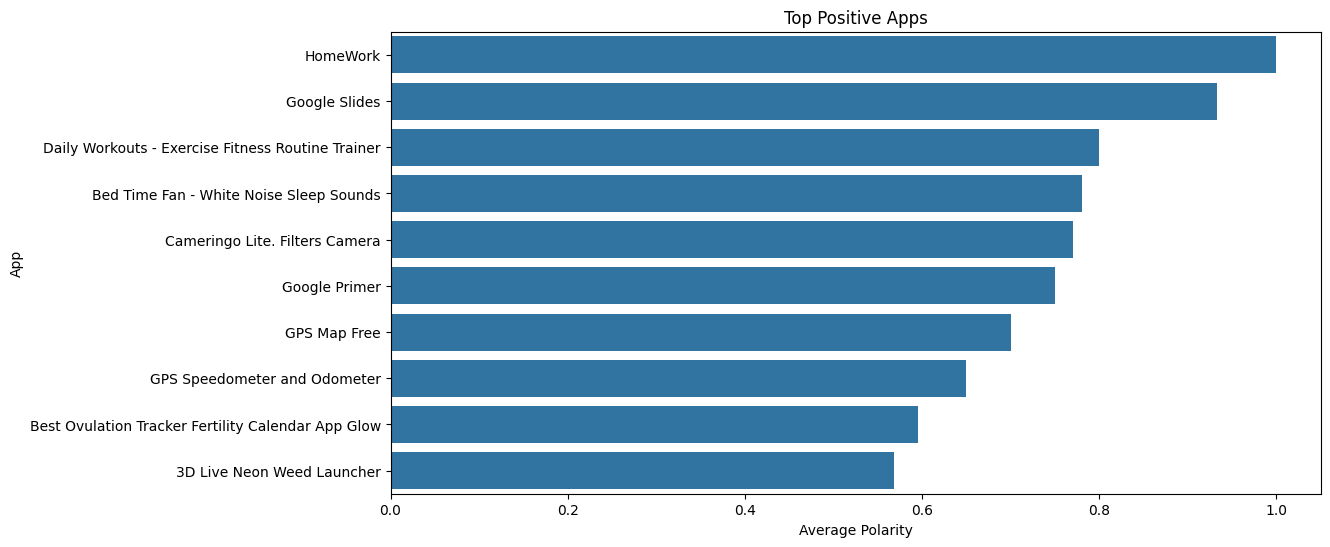

In [30]:
# Plot Top Positive Apps
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_positive_apps.values,
    y=top_positive_apps.index
)

plt.title("Top Positive Apps")
plt.xlabel("Average Polarity")
plt.ylabel("App")

plt.show()

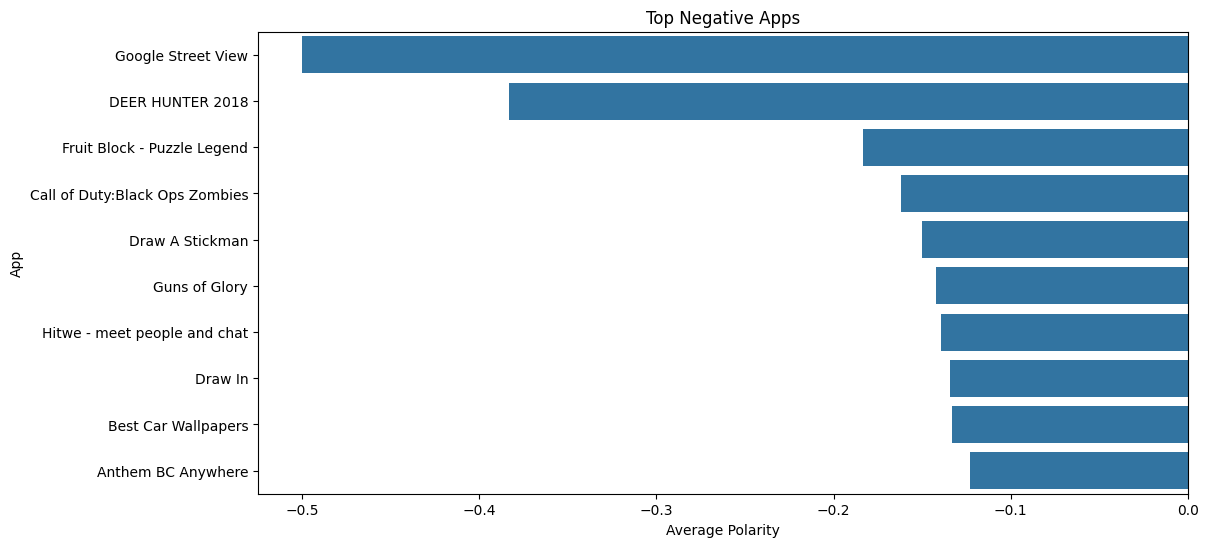

In [31]:
# Plot Top Negative Apps
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_negative_apps.values,
    y=top_negative_apps.index
)

plt.title("Top Negative Apps")
plt.xlabel("Average Polarity")
plt.ylabel("App")

plt.show()

In [32]:
review_df.to_csv(
    "..\\Data\\Cleaned_Data\\review_sentiment_eda_dataset.csv",
    index=False
)